# Customer Churn Prediction — Data Preprocessing & Feature Engineering
**Week 10** — Full preprocessing pipeline: encoding, scaling, outlier handling, feature engineering, feature selection, and an end-to-end pipeline.


## Day 1: Explore & Understand

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
df = pd.read_csv('customer_churn.csv')
df.shape

(500, 9)

In [5]:
df.head()

,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
0,C00001,6,64,1540,One year,Credit Card,No,1,0
1,C00002,21,113,1753,Month-to-month,Electronic Check,Yes,1,0
2,C00003,27,31,1455,Two year,Credit Card,No,1,0
3,C00004,53,29,7150,Month-to-month,Electronic Check,No,1,0
4,C00005,16,185,1023,One year,Electronic Check,No,1,0


In [6]:
df.dtypes

CustomerID          object
Tenure               int64
MonthlyCharges       int64
TotalCharges         int64
Contract            object
PaymentMethod       object
PaperlessBilling    object
SeniorCitizen        int64
Churn                int64
dtype: object

In [7]:
print("Missing values:\n", df.isnull().sum())
print("\nChurn distribution:\n", df['Churn'].value_counts(normalize=True))

Missing values:
 CustomerID          0
Tenure              0
MonthlyCharges      0
TotalCharges        0
Contract            0
PaymentMethod       0
PaperlessBilling    0
SeniorCitizen       0
Churn               0
dtype: int64

Churn distribution:
 Churn
0    0.894
1    0.106
Name: proportion, dtype: float64


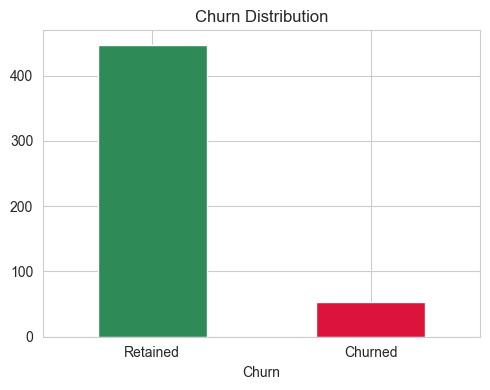

In [8]:
plt.figure(figsize=(5,4))
df['Churn'].value_counts().plot(kind='bar', color=['seagreen','crimson'])
plt.title('Churn Distribution')
plt.xticks([0,1], ['Retained','Churned'], rotation=0)
plt.tight_layout()
plt.savefig('churn_distribution.png', dpi=150)
plt.show()

## Day 2: Handle Categorical Data

Three encoding methods are demonstrated:
1. **Label Encoding** — for binary/ordinal categories (PaperlessBilling)
2. **One-Hot Encoding** — for nominal categories (Contract, PaymentMethod)
3. **Ordinal Encoding** — for a naturally ordered category (Contract: Month-to-month < One year < Two year)


In [9]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder

df_enc = df.copy()

# 1. Label Encoding - binary categorical column
le = LabelEncoder()
df_enc['PaperlessBilling_Label'] = le.fit_transform(df_enc['PaperlessBilling'])
print("Label Encoding classes:", le.classes_)

Label Encoding classes: ['No' 'Yes']


In [10]:
# 2. One-Hot Encoding - nominal categorical columns
ohe = OneHotEncoder(sparse_output=False, drop='first')
ohe_array = ohe.fit_transform(df_enc[['Contract', 'PaymentMethod']])
ohe_cols = ohe.get_feature_names_out(['Contract', 'PaymentMethod'])
ohe_df = pd.DataFrame(ohe_array, columns=ohe_cols, index=df_enc.index)
df_enc = pd.concat([df_enc, ohe_df], axis=1)
df_enc[ohe_cols].head()

,Contract_One year,Contract_Two year,PaymentMethod_Credit Card,PaymentMethod_Electronic Check
0,1.0,0.0,1.0,0.0
1,0.0,0.0,0.0,1.0
2,0.0,1.0,1.0,0.0
3,0.0,0.0,0.0,1.0
4,1.0,0.0,0.0,1.0


In [11]:
# 3. Ordinal Encoding - Contract has a natural order (short -> long commitment)
contract_order = [['Month-to-month', 'One year', 'Two year']]
ord_enc = OrdinalEncoder(categories=contract_order)
df_enc['Contract_Ordinal'] = ord_enc.fit_transform(df_enc[['Contract']])
df_enc[['Contract', 'Contract_Ordinal']].drop_duplicates()

,Contract,Contract_Ordinal
0,One year,1.0
1,Month-to-month,0.0
2,Two year,2.0


## Day 3: Feature Scaling

Two scaling techniques applied and compared:
- **Min-Max Scaling** — rescales to [0, 1]
- **Standard Scaling (Z-score)** — mean 0, std 1


In [12]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

num_cols = ['Tenure', 'MonthlyCharges', 'TotalCharges']

minmax_scaler = MinMaxScaler()
df_enc[[c + '_minmax' for c in num_cols]] = minmax_scaler.fit_transform(df_enc[num_cols])

standard_scaler = StandardScaler()
df_enc[[c + '_standard' for c in num_cols]] = standard_scaler.fit_transform(df_enc[num_cols])

df_enc[num_cols + [c + '_minmax' for c in num_cols] + [c + '_standard' for c in num_cols]].describe()

,Tenure,MonthlyCharges,TotalCharges,Tenure_minmax,MonthlyCharges_minmax,TotalCharges_minmax,Tenure_standard,MonthlyCharges_standard,TotalCharges_standard
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,5.000000e+02,5.000000e+02,5.000000e+02
mean,36.532000,113.636000,4237.882000,0.507600,0.523106,0.520730,1.731948e-16,8.881784e-17,1.767475e-16
std,20.667057,51.799903,2260.619837,0.295244,0.289385,0.288602,1.001002e+00,1.001002e+00,1.001002e+00
min,1.000000,20.000000,159.000000,0.000000,0.000000,0.000000,-1.720980e+00,-1.809459e+00,-1.806127e+00
25%,19.000000,67.000000,2237.250000,0.257143,0.262570,0.265320,-8.491562e-01,-9.012122e-01,-8.858790e-01
50%,37.000000,115.000000,4182.500000,0.514286,0.530726,0.513660,2.266741e-02,2.635847e-02,-2.452313e-02
75%,54.000000,158.000000,6266.750000,0.757143,0.770950,0.779746,8.460563e-01,8.573072e-01,8.983819e-01
max,71.000000,199.000000,7992.000000,1.000000,1.000000,1.000000,1.669445e+00,1.649607e+00,1.662322e+00


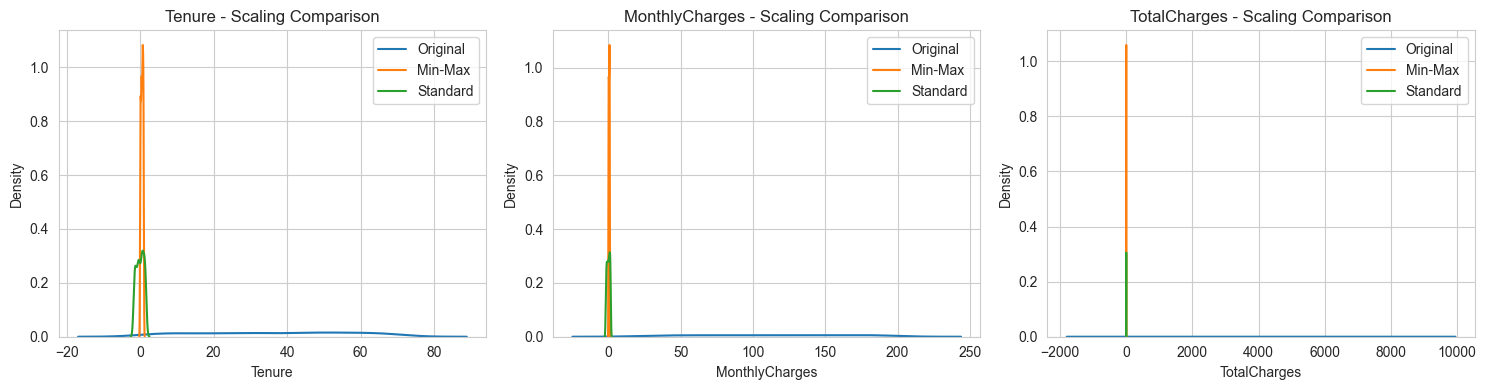

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, col in zip(axes, num_cols):
    sns.kdeplot(df_enc[col], label='Original', ax=ax)
    sns.kdeplot(df_enc[col + '_minmax'], label='Min-Max', ax=ax)
    sns.kdeplot(df_enc[col + '_standard'], label='Standard', ax=ax)
    ax.set_title(f'{col} - Scaling Comparison')
    ax.legend()
plt.tight_layout()
plt.savefig('scaling_comparison.png', dpi=150)
plt.show()

## Day 4: Outlier Detection & Handling

Two methods used:
- **IQR method** — flags points outside [Q1 - 1.5*IQR, Q3 + 1.5*IQR]
- **Z-score method** — flags points with |z| > 3


In [14]:
def iqr_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return (series < lower) | (series > upper)

def zscore_outliers(series, threshold=3):
    z = (series - series.mean()) / series.std()
    return z.abs() > threshold

for col in num_cols:
    iqr_flag = iqr_outliers(df_enc[col])
    z_flag = zscore_outliers(df_enc[col])
    print(f"{col}: IQR outliers = {iqr_flag.sum()}, Z-score outliers = {z_flag.sum()}")

Tenure: IQR outliers = 0, Z-score outliers = 0
MonthlyCharges: IQR outliers = 0, Z-score outliers = 0
TotalCharges: IQR outliers = 0, Z-score outliers = 0


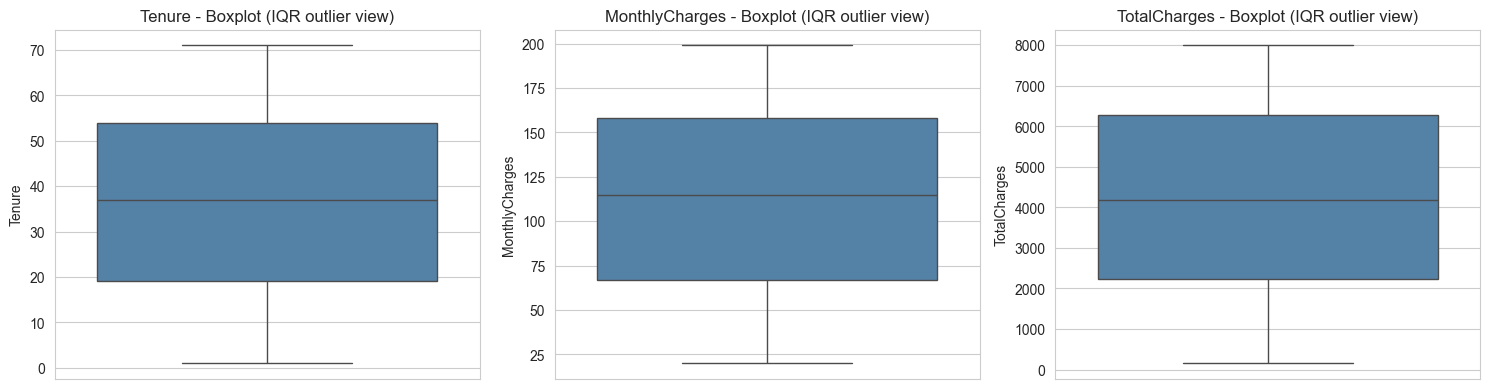

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, col in zip(axes, num_cols):
    sns.boxplot(y=df_enc[col], ax=ax, color='steelblue')
    ax.set_title(f'{col} - Boxplot (IQR outlier view)')
plt.tight_layout()
plt.savefig('outlier_boxplots.png', dpi=150)
plt.show()

In [16]:
# Handling: cap outliers at IQR bounds (winsorizing) rather than dropping rows,
# to preserve sample size on this already-modest dataset.
df_clean = df_enc.copy()
for col in num_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_capped = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    df_clean[col] = df_clean[col].clip(lower, upper)
    print(f"{col}: {n_capped} values capped to [{lower:.1f}, {upper:.1f}]")

Tenure: 0 values capped to [-33.5, 106.5]
MonthlyCharges: 0 values capped to [-69.5, 294.5]
TotalCharges: 0 values capped to [-3807.0, 12311.0]


## Day 5: Feature Engineering

Five+ new engineered features:
1. **AvgMonthlySpend** = TotalCharges / Tenure
2. **CustomerLifetimeValue (CLV)** = MonthlyCharges * Tenure
3. **PaymentEfficiency** = TotalCharges / (MonthlyCharges * Tenure) — closeness of actual vs. expected billing
4. **TenureGroup** — binned tenure (New / Established / Loyal)
5. **HighValueCustomer** — flag for above-median MonthlyCharges
6. **IsLongTermContract** — binary flag for One/Two year contracts


In [17]:
fe = df_clean.copy()

# 1. Average monthly spend (normalizes total spend by tenure)
fe['AvgMonthlySpend'] = (fe['TotalCharges'] / fe['Tenure'].replace(0, 1)).round(2)

# 2. Customer Lifetime Value (simple proxy: current rate * tenure so far)
fe['CustomerLifetimeValue'] = (fe['MonthlyCharges'] * fe['Tenure']).round(2)

# 3. Payment Efficiency (ratio of actual to expected total charges)
expected_total = fe['MonthlyCharges'] * fe['Tenure'].replace(0, 1)
fe['PaymentEfficiency'] = (fe['TotalCharges'] / expected_total).round(3)

# 4. Tenure Group (binned)
fe['TenureGroup'] = pd.cut(fe['Tenure'], bins=[0, 12, 36, 100],
                            labels=['New', 'Established', 'Loyal'])

# 5. High Value Customer flag
fe['HighValueCustomer'] = (fe['MonthlyCharges'] > fe['MonthlyCharges'].median()).astype(int)

# 6. Long-term contract flag
fe['IsLongTermContract'] = fe['Contract'].isin(['One year', 'Two year']).astype(int)

fe[['AvgMonthlySpend','CustomerLifetimeValue','PaymentEfficiency','TenureGroup',
    'HighValueCustomer','IsLongTermContract']].head()

,AvgMonthlySpend,CustomerLifetimeValue,PaymentEfficiency,TenureGroup,HighValueCustomer,IsLongTermContract
0,256.67,384,4.010,New,0,1
1,83.48,2373,0.739,Established,0,0
2,53.89,837,1.738,Established,0,1
3,134.91,1537,4.652,Loyal,0,0
4,63.94,2960,0.346,Established,1,1


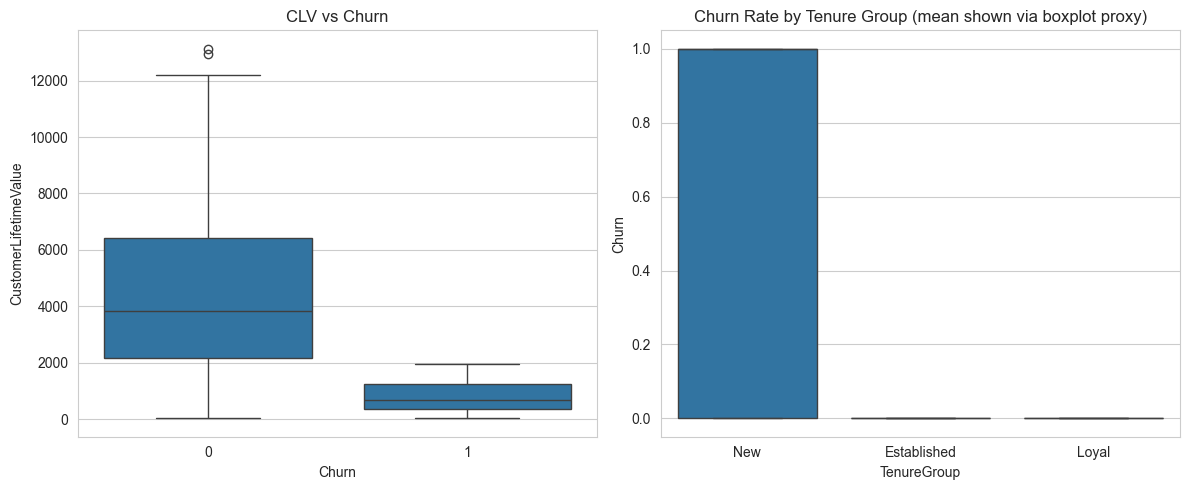

TenureGroup
New            0.630952
Established    0.000000
Loyal          0.000000
Name: Churn, dtype: float64


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.boxplot(data=fe, x='Churn', y='CustomerLifetimeValue', ax=axes[0])
axes[0].set_title('CLV vs Churn')
sns.boxplot(data=fe, x='TenureGroup', y='Churn', ax=axes[1])
axes[1].set_title('Churn Rate by Tenure Group (mean shown via boxplot proxy)')
plt.tight_layout()
plt.savefig('engineered_features.png', dpi=150)
plt.show()

print(fe.groupby('TenureGroup', observed=True)['Churn'].mean())

## Day 6: Feature Selection

Using correlation analysis and Random Forest feature importance to identify the most predictive features.


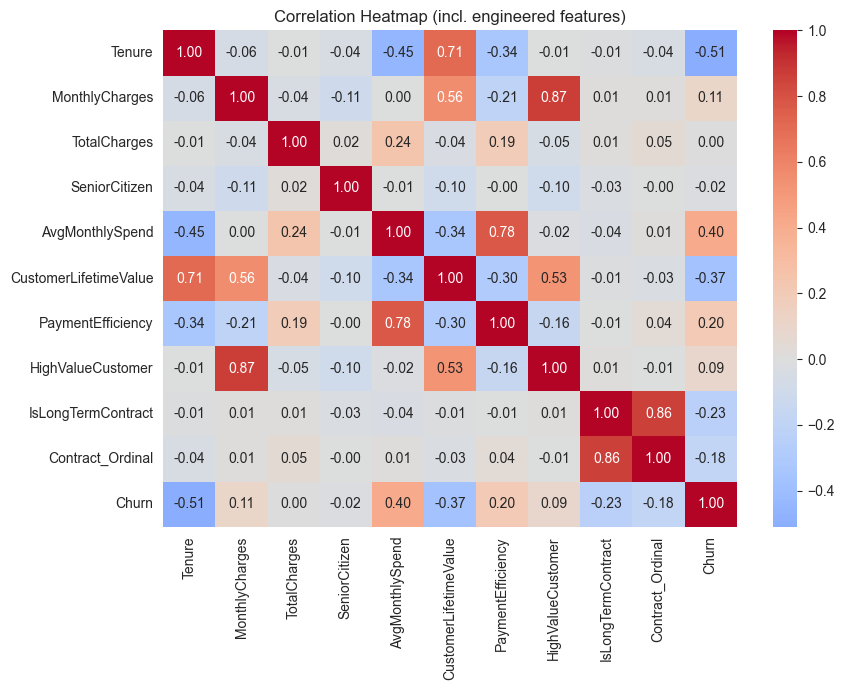

Correlation with Churn:
 AvgMonthlySpend          0.404714
PaymentEfficiency        0.204446
MonthlyCharges           0.107381
HighValueCustomer        0.087218
TotalCharges             0.004250
SeniorCitizen           -0.018114
Contract_Ordinal        -0.182759
IsLongTermContract      -0.232881
CustomerLifetimeValue   -0.367997
Tenure                  -0.509208
Name: Churn, dtype: float64


In [19]:
numeric_feature_cols = ['Tenure','MonthlyCharges','TotalCharges','SeniorCitizen',
                         'AvgMonthlySpend','CustomerLifetimeValue','PaymentEfficiency',
                         'HighValueCustomer','IsLongTermContract','Contract_Ordinal','Churn']

corr = fe[numeric_feature_cols].corr()
plt.figure(figsize=(9,7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap (incl. engineered features)')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

print("Correlation with Churn:\n", corr['Churn'].drop('Churn').sort_values(ascending=False))

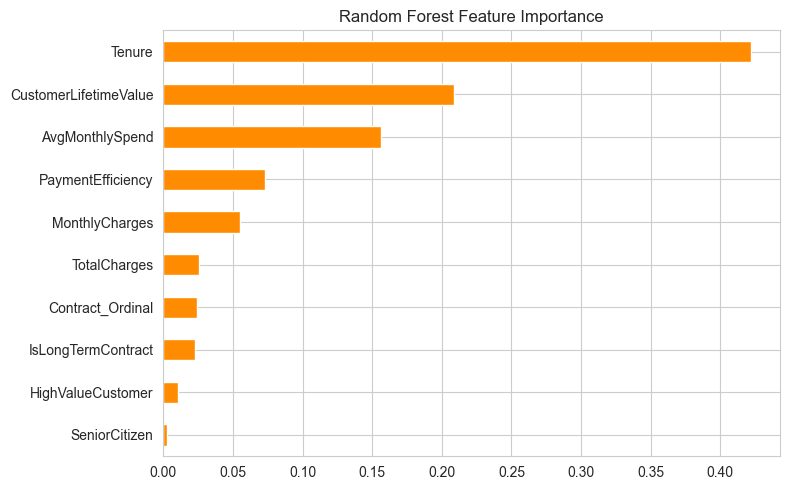

Tenure                   0.421826
CustomerLifetimeValue    0.208924
AvgMonthlySpend          0.156441
PaymentEfficiency        0.072888
MonthlyCharges           0.054962
TotalCharges             0.025683
Contract_Ordinal         0.024086
IsLongTermContract       0.022390
HighValueCustomer        0.010424
SeniorCitizen            0.002375
dtype: float64

In [20]:
from sklearn.ensemble import RandomForestClassifier

X_fs = fe[numeric_feature_cols].drop(columns=['Churn'])
y_fs = fe['Churn']

rf = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42, class_weight='balanced')
rf.fit(X_fs, y_fs)

importance = pd.Series(rf.feature_importances_, index=X_fs.columns).sort_values(ascending=False)
plt.figure(figsize=(8,5))
importance.plot(kind='barh', color='darkorange')
plt.gca().invert_yaxis()
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()
importance

In [21]:
# Select top features based on combined correlation + importance signal
selected_features = importance.head(6).index.tolist()
print("Selected features for modeling:", selected_features)

Selected features for modeling: ['Tenure', 'CustomerLifetimeValue', 'AvgMonthlySpend', 'PaymentEfficiency', 'MonthlyCharges', 'TotalCharges']


## Day 7: Build Complete Preprocessing Pipeline

Using scikit-learn's `ColumnTransformer` + `Pipeline` to combine encoding, scaling, and outlier-robust
preprocessing into a single reusable object, then testing it end-to-end with a classifier.


In [22]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

# Start from the original raw-ish dataframe (pre-engineering) to build a realistic pipeline
raw = df.copy()
raw['AvgMonthlySpend'] = (raw['TotalCharges'] / raw['Tenure'].replace(0,1)).round(2)
raw['CustomerLifetimeValue'] = (raw['MonthlyCharges'] * raw['Tenure']).round(2)
raw['IsLongTermContract'] = raw['Contract'].isin(['One year','Two year']).astype(int)

numeric_features = ['Tenure','MonthlyCharges','TotalCharges','AvgMonthlySpend',
                     'CustomerLifetimeValue','SeniorCitizen','IsLongTermContract']
categorical_features = ['Contract','PaymentMethod','PaperlessBilling']

numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first')),
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features),
])

full_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=200, max_depth=6,
                                           random_state=42, class_weight='balanced')),
])

X = raw[numeric_features + categorical_features]
y = raw['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                      random_state=42, stratify=y)

full_pipeline.fit(X_train, y_train)
pred = full_pipeline.predict(X_test)
proba = full_pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, pred))
print(f"ROC-AUC: {roc_auc_score(y_test, proba):.3f}")

              precision    recall  f1-score   support

           0       0.97      1.00      0.98        89
           1       1.00      0.73      0.84        11

    accuracy                           0.97       100
   macro avg       0.98      0.86      0.91       100
weighted avg       0.97      0.97      0.97       100

ROC-AUC: 0.999


In [24]:
# Save the final engineered + cleaned dataset for downstream use
fe.to_csv('churn_data_processed.csv', index=False)
print("Saved: churn_data_processed.csv, shape =", fe.shape)

Saved: churn_data_processed.csv, shape = (500, 27)


### Pipeline Summary

The end-to-end pipeline performs, in order:
1. Missing-value imputation (median for numeric, mode for categorical)
2. Standard scaling for numeric features
3. One-hot encoding for categorical features
4. Random Forest classification

This single `full_pipeline` object can be called with `.fit()` / `.predict()` on new raw data without any manual preprocessing steps, making it production-ready and easy to serialize (e.g. via `joblib`).
